# **TRUSTPAW AI - EARLY DOG ILLNESS DETECTION SYSTEM**

## **CNN+LSTM HYBRID MODEL FOR BEHAVIORAL VIDEO ANALYSIS**

Herath Mudiyanselage Nethmini<br>
20221487 | w1956416<br>
Final Year Project

### **PROJECT OVERVIEW**

This research describes an AI-powered system that uses non-invasive behavioural video analysis to identify dog illnesses early. The technology seeks to detect possible health problems before obvious symptoms worsen by examining small variations in a dog's behaviour and movement.

**Key Innovation:** For health screening applications, the conservative threshold (t=0.5) ensures early detection at the cost of some false positives by prioritising recall over precision.

### **SYSTEM ARCHITECTURE**

### **DEEP LEARNING PIPELINE**

- **Spatial Feature Extraction:** MobileNetV2 (frozen, ImageNet pre-trained)
- **Temporal Pattern Recognition:** Stacked LSTM layers (256→128 units)
- **Classification:** Dense layers with L2 regularization + Dropout
- **Explainable AI:** Natural language behavioral insights

### **MODEL SPECIFICATIONS**

- **Input:** 30 frames × 224×224 RGB (evenly sampled from video)
- **Total Parameters:** 4,040,385 (1,782,401 trainable)
- **Optimizer:** Adam (lr=0.0001)
- **Loss Function:** Binary Crossentropy
- **Decision Threshold:** 0.5 (conservative for health screening)

### **DATASET**

**Class Balance:** 50% Normal / 50% Abnormal  
**Train/Val/Test Split:** 70% / 15% / 15% (stratified)

### **DATASET CITATIONS:**

- **DECADE** - Normal dog behavior: Ehsanik. (no date). GitHub - ehsanik/dogTorch: Who Let The Dogs Out? Modeling Dog Behavior From Visual Data. Available from https://arxiv.org/pdf/1803.10827.pdf. GitHub. https://github.com/ehsanik/dogTorch [Accessed 16 Nov. 2025].
‌
- **HuggingFace** - Behavioral diversity: https://huggingface.co/datasets/UniqueData/dogs-video-object-tracking-dataset. Available from https://huggingface.co/datasets/UniqueData/dogs-video-object-tracking-dataset [Accessed 16 Nov. 2025].
  
- **Zenodo Dog Pain DB V2** - Pain/abnormal behavior indicators: Bremhorst, A. (2025). Dog Pain Database: A Multidimensional Dataset for Investigating Canine Pain. Zenodo. Available from https://zenodo.org/records/15304081 [Accessed 26 October 2025].

## **ENVIRONMENT SETUP**

In [1]:
# ============================================
# SETUP & IMPORTS
# ============================================

import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("\n" + "="*80)
print("TRUSTPAW AI - EARLY DOG ILLNESS DETECTION SYSTEM")
print("="*80)
print(f"\nTensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPUs Available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("    No GPU")

# Paths
KAGGLE_INPUT = '/kaggle/input'
WORKING_DIR = '/kaggle/working'

# Create directories
os.makedirs(f'{WORKING_DIR}/models', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/tables', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/plots', exist_ok=True)

print("\n" + "="*80)
print(" SETUP COMPLETE!")
print("="*80)

2026-03-28 19:40:35.024291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774726835.214997      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774726835.269491      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774726835.700213      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774726835.700264      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774726835.700270      55 computation_placer.cc:177] computation placer alr


TRUSTPAW AI - EARLY DOG ILLNESS DETECTION SYSTEM

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.3.3

GPUs Available: 2
  /physical_device:GPU:0
  /physical_device:GPU:1

 SETUP COMPLETE!


## **CONFIGURATION PARAMETERS**

In [2]:
# ================================================================================
# CONFIGURATION PARAMETERS
# ================================================================================

# Random Seeds
RANDOM_SEED = 42
RANDOM_STATE = 42

# Data Parameters
TEST_SIZE = 0.20
N_FOLDS = 5

# Training Parameters
BATCH_SIZE = 8
MAX_EPOCHS = 15
PATIENCE = 3
LEARNING_RATE = 0.0001

# Evaluation Parameters
THRESHOLD = 0.3

# Paths
WORKING_DIR = '/kaggle/working'
RESULTS_DIR = f'{WORKING_DIR}/plots'
MODELS_DIR = f'{WORKING_DIR}/models'
TABLES_DIR = f'{WORKING_DIR}/tables'


## **LOAD PREPROCESSED DATA**

## **BUILD MODEL ARCHITECTURE**

In [3]:
# ============================================
# LOAD PREPROCESSED DATA
# ============================================

print("\n" + "="*80)
print("LOADING PREPROCESSED DATA")
print("="*80)

DATA_PATH = '/kaggle/input/datasets/nethminiherath/dog-illness-detection-processed-data'

# Verify path exists
import os
if not os.path.exists(DATA_PATH):
    print(f" ERROR: Dataset not found at {DATA_PATH}")
    print("\nPlease verify that your Google Drive is mounted correctly!")
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

print(f"\n Dataset path: {DATA_PATH}")
print(f"   Contents: {os.listdir(DATA_PATH)}")

# Load data
print(f"\n Loading data files...")
normal_data = np.load(os.path.join(DATA_PATH, 'normal_data.npy'))
abnormal_data = np.load(os.path.join(DATA_PATH, 'abnormal_data.npy'))

print(f"\n Data loaded:")
print(f"  Normal: {normal_data.shape}")
print(f"  Abnormal: {abnormal_data.shape}")

# Verify data normalization
print(f"\n Data validation:")
print(f"  Normal data range: [{normal_data.min():.3f}, {normal_data.max():.3f}]")
print(f"  Abnormal data range: [{abnormal_data.min():.3f}, {abnormal_data.max():.3f}]")

if normal_data.max() > 1.0 or normal_data.min() < 0.0:
    print("    Data not normalized - normalizing now...")
    normal_data = normal_data / 255.0
    abnormal_data = abnormal_data / 255.0
    print("   Data normalized to [0, 1]")

# Balance dataset
min_samples = min(len(normal_data), len(abnormal_data))
normal_data = normal_data[:min_samples]
abnormal_data = abnormal_data[:min_samples]

print(f"\n Balanced to {min_samples} samples per class")

# Combine and shuffle
X = np.concatenate([normal_data, abnormal_data])
y = np.array([0] * min_samples + [1] * min_samples)

del normal_data, abnormal_data
import gc
gc.collect()

from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=100)

print(f"\n Final dataset:")
print(f"  Shape: {X.shape}")
print(f"  Total: {len(X)} videos")
print(f"  Normal: {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")
print(f"  Abnormal: {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")

print("="*80)


LOADING PREPROCESSED DATA

 Dataset path: /kaggle/input/datasets/nethminiherath/dog-illness-detection-processed-data
   Contents: ['normal_data.npy', 'abnormal_data.npy']

 Loading data files...

 Data loaded:
  Normal: (85, 30, 224, 224, 3)
  Abnormal: (80, 30, 224, 224, 3)

 Data validation:
  Normal data range: [0.000, 1.000]
  Abnormal data range: [0.000, 1.000]

 Balanced to 80 samples per class

 Final dataset:
  Shape: (160, 30, 224, 224, 3)
  Total: 160 videos
  Normal: 80 (50.0%)
  Abnormal: 80 (50.0%)


In [4]:
# ============================================
# MODEL DEFINITION
# ============================================

THRESHOLD = 0.3  # Conservative threshold for health screening

def build_model(freeze_base=True):
    """
    Build CNN+LSTM hybrid model

    Args:
        freeze_base: If True, freeze MobileNetV2 weights

    Returns:
        Compiled model
    """

    video_input = layers.Input(shape=(30, 224, 224, 3), name='video_input')

    # CNN Backbone
    base_cnn = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_cnn.trainable = not freeze_base

    cnn_model = tf.keras.Sequential([
        base_cnn,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3)
    ], name='cnn_extractor')

    cnn_features = layers.TimeDistributed(cnn_model)(video_input)

    # LSTM Layers (NO recurrent_dropout - causes compatibility issues)
    lstm_out = layers.LSTM(
        256,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(0.01),
        name='lstm_1'
    )(cnn_features)
    lstm_out = layers.Dropout(0.5)(lstm_out)

    lstm_out = layers.LSTM(
        128,
        kernel_regularizer=regularizers.l2(0.01),
        name='lstm_2'
    )(lstm_out)
    lstm_out = layers.Dropout(0.5)(lstm_out)

    # Dense Layers
    dense_out = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),
        name='dense_1'
    )(lstm_out)
    dense_out = layers.Dropout(0.3)(dense_out)

    dense_out = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),
        name='dense_2'
    )(dense_out)
    dense_out = layers.Dropout(0.4)(dense_out)

    # Output
    output = layers.Dense(1, activation='sigmoid', name='output')(dense_out)

    # Create model
    model = Model(inputs=video_input, outputs=output, name='TrustPaw_AI')

    # Compile
    lr = 0.0001 if freeze_base else 0.00001
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model

print("\n" + "="*80)
print("MODEL ARCHITECTURE DEFINED")
print("="*80)
print("\n CNN Backbone: MobileNetV2 (ImageNet pretrained)")
print(" LSTM Layers: 256 → 128 units")
print(" Dense Layers: 64 → 32 units")
print(" Output: Binary classification (sigmoid)")
print(f" Threshold: {THRESHOLD} (conservative for health screening)")
print("="*80)


MODEL ARCHITECTURE DEFINED

 CNN Backbone: MobileNetV2 (ImageNet pretrained)
 LSTM Layers: 256 → 128 units
 Dense Layers: 64 → 32 units
 Output: Binary classification (sigmoid)
 Threshold: 0.3 (conservative for health screening)


## **5-FOLD CROSS-VALIDATION**

In [ ]:
# ============================================
# TRAIN/TEST SPLIT + 5-FOLD CV + EVALUATION
# ============================================

print("\n" + "="*80)
print("TRAIN/TEST SPLIT + 5-FOLD CROSS-VALIDATION")
print("="*80)

# Hold out test set (20%) - NEVER seen during training
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"\n Data split:")
print(f"  Training pool (for CV): {len(X_temp)} samples (85%)")
print(f"  Test set (held out):    {len(X_test)} samples (15%)")
print(f"    Test normal:   {np.sum(y_test==0)}")
print(f"    Test abnormal: {np.sum(y_test==1)}")

# 5-Fold CV on training pool only
N_SPLITS = 5
BATCH_SIZE = 8
EPOCHS = 50
THRESHOLD = 0.3

print(f"\n Cross-validation setup:")
print(f"  Folds: {N_SPLITS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Threshold: {THRESHOLD}")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
all_y_true = []
all_y_pred_probs = []
aggregated_cm = np.zeros((2, 2), dtype=int)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp), 1):
    print(f"\n{'-'*80}")
    print(f"FOLD {fold}/{N_SPLITS}")
    print(f"{'-'*80}")

    X_train, X_val = X_temp[train_idx], X_temp[val_idx]
    y_train, y_val = y_temp[train_idx], y_temp[val_idx]

    print(f"  Train: {len(X_train)} samples")
    print(f"  Val: {len(X_val)} samples")

    # Build model
    model = build_model(freeze_base=True)

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=0
        )
    ]

    # Train
    print(f"\n Training fold {fold}...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    print(f"   Training complete ({len(history.history['loss'])} epochs)")

    # Predict
    y_pred_prob = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).flatten()
    y_pred = (y_pred_prob > THRESHOLD).astype(int)

    # Store for aggregation
    all_y_true.extend(y_val)
    all_y_pred_probs.extend(y_pred_prob)

    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc_val = roc_auc_score(y_val, y_pred_prob)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    aggregated_cm += cm
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n  Results:")
    print(f"    Accuracy:    {acc*100:.2f}%")
    print(f"    Precision:   {prec*100:.2f}%")
    print(f"    Recall:      {rec*100:.2f}%")
    print(f"    Specificity: {spec*100:.2f}%")
    print(f"    F1-Score:    {f1:.4f}")
    print(f"    AUC:         {auc_val:.4f}")

    cv_results.append({
        'Fold': fold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'F1-Score': f1,
        'AUC': auc_val
    })

    # Clean up
    del model, X_train, X_val, y_train, y_val
    gc.collect()
    tf.keras.backend.clear_session()

# Save CV results
cv_df = pd.DataFrame(cv_results)
display(cv_df)
cv_df.to_csv(f'{WORKING_DIR}/tables/table_1_cv_folds.csv', index=False)

# Summary
print(f"\n{'='*80}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*80}")
print(f"  Mean Accuracy:    {cv_df['Accuracy'].mean()*100:.2f}% ± {cv_df['Accuracy'].std()*100:.2f}%")
print(f"  Mean Precision:   {cv_df['Precision'].mean()*100:.2f}% ± {cv_df['Precision'].std()*100:.2f}%")
print(f"  Mean Recall:      {cv_df['Recall'].mean()*100:.2f}% ± {cv_df['Recall'].std()*100:.2f}%")
print(f"  Mean Specificity: {cv_df['Specificity'].mean()*100:.2f}% ± {cv_df['Specificity'].std()*100:.2f}%")
print(f"  Mean F1-Score:    {cv_df['F1-Score'].mean():.4f} ± {cv_df['F1-Score'].std():.4f}")
print(f"  Mean AUC:         {cv_df['AUC'].mean():.4f} ± {cv_df['AUC'].std():.4f}")

# Save summary
summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC'],
    'Mean': [
        cv_df['Accuracy'].mean(),
        cv_df['Precision'].mean(),
        cv_df['Recall'].mean(),
        cv_df['Specificity'].mean(),
        cv_df['F1-Score'].mean(),
        cv_df['AUC'].mean()
    ],
    'Std': [
        cv_df['Accuracy'].std(),
        cv_df['Precision'].std(),
        cv_df['Recall'].std(),
        cv_df['Specificity'].std(),
        cv_df['F1-Score'].std(),
        cv_df['AUC'].std()
    ]
})
display(summary_df)
summary_df.to_csv(f'{WORKING_DIR}/tables/table_2_cv_summary.csv', index=False)

print("\n Table 1 saved: table_1_cv_folds.csv")
print(" Table 2 saved: table_2_cv_summary.csv")

# Train final model on full training pool
print(f"\n{'='*80}")
print("TRAINING FINAL MODEL ON FULL TRAINING POOL")
print(f"{'='*80}")

print(f"\n Training on {len(X_temp)} samples...")
final_model = build_model(freeze_base=True)

callbacks = [
    EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{WORKING_DIR}/models/best_model_frozen.keras',
        monitor='loss',
        save_best_only=True,
        verbose=1
    )
]

final_history = final_model.fit(
    X_temp, y_temp,
    epochs=MAX_EPOCHS,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

print(f"\n Final model trained ({len(final_history.history['loss'])} epochs)")

# Evaluate on held-out test set
print(f"\n{'='*80}")
print("EVALUATING ON HELD-OUT TEST SET")
print(f"{'='*80}")

print(f"\n Testing on {len(X_test)} unseen samples...")
y_test_pred_prob = final_model.predict(X_test, batch_size=8, verbose=0).flatten()
y_test_pred = (y_test_pred_prob > THRESHOLD).astype(int)

# Calculate test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test, y_test_pred_prob)

# Confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = test_cm.ravel()
test_spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n{'='*80}")
print("TEST SET RESULTS (Unseen Data)")
print(f"{'='*80}")
print(f"  Accuracy:    {test_acc*100:.2f}%")
print(f"  Precision:   {test_prec*100:.2f}%")
print(f"  Recall:      {test_rec*100:.2f}%")
print(f"  Specificity: {test_spec*100:.2f}%")
print(f"  F1-Score:    {test_f1:.4f}")
print(f"  AUC:         {test_auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN: {tn}  FP: {fp}")
print(f"    FN: {fn}  TP: {tp}")

# Save test metrics
test_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC'],
    'Value': [test_acc, test_prec, test_rec, test_spec, test_f1, test_auc],
    'Percentage': [f'{test_acc*100:.2f}%', f'{test_prec*100:.2f}%', f'{test_rec*100:.2f}%',
                  f'{test_spec*100:.2f}%', f'{test_f1*100:.2f}%', f'{test_auc*100:.2f}%']
})
display(test_df)
test_df.to_csv(f'{WORKING_DIR}/tables/table_3_test_metrics.csv', index=False)

print("\n Table 3 saved: table_3_test_metrics.csv")
print("="*80)

# Store aggregated results for plotting
np.save(f'{WORKING_DIR}/all_y_true.npy', all_y_true)
np.save(f'{WORKING_DIR}/all_y_pred_probs.npy', all_y_pred_probs)
np.save(f'{WORKING_DIR}/aggregated_cm.npy', aggregated_cm)

cv_pool_size = len(X_temp)

# Clean up
del X_temp, y_temp
gc.collect()



TRAIN/TEST SPLIT + 5-FOLD CROSS-VALIDATION

 Data split:
  Training pool (for CV): 128 samples (85%)
  Test set (held out):    32 samples (15%)
    Test normal:   16
    Test abnormal: 16

 Cross-validation setup:
  Folds: 5
  Batch size: 8
  Max epochs: 50
  Threshold: 0.3

--------------------------------------------------------------------------------
FOLD 1/5
--------------------------------------------------------------------------------
  Train: 102 samples
  Val: 26 samples


I0000 00:00:1774726881.352073      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774726881.357943      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Training fold 1...


I0000 00:00:1774726999.556132     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


   Training complete (50 epochs)

  Results:
    Accuracy:    76.92%
    Precision:   81.82%
    Recall:      69.23%
    Specificity: 84.62%
    F1-Score:    0.7500
    AUC:         0.8639

--------------------------------------------------------------------------------
FOLD 2/5
--------------------------------------------------------------------------------
  Train: 102 samples
  Val: 26 samples

 Training fold 2...
   Training complete (50 epochs)

  Results:
    Accuracy:    76.92%
    Precision:   76.92%
    Recall:      76.92%
    Specificity: 76.92%
    F1-Score:    0.7692
    AUC:         0.9112

--------------------------------------------------------------------------------
FOLD 3/5
--------------------------------------------------------------------------------
  Train: 102 samples
  Val: 26 samples

 Training fold 3...
   Training complete (50 epochs)

  Results:
    Accuracy:    65.38%
    Precision:   70.00%
    Recall:      53.85%
    Specificity: 76.92%
    F1-Score:    

...

,Metric,Mean,Std
0,Accuracy,0.750462,0.068891
1,Precision,0.857483,0.136708
2,Recall,0.625641,0.123769
3,Specificity,0.876923,0.116660
4,F1-Score,0.711901,0.086027
5,AUC,0.811144,0.087034



 Table 1 saved: table_1_cv_folds.csv
 Table 2 saved: table_2_cv_summary.csv

TRAINING FINAL MODEL ON FULL TRAINING POOL

 Training on 128 samples...
Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.4587 - auc: 0.4421 - loss: 16.6563 - precision: 0.4719 - recall: 0.8952
Epoch 1: loss improved from inf to 16.46204, saving model to /kaggle/working/models/best_model_frozen.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 116s 524ms/step - accuracy: 0.4629 - auc: 0.4479 - loss: 16.6448 - precision: 0.4747 - recall: 0.8931
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.5360 - auc: 0.6162 - loss: 15.9477 - precision: 0.5143 - recall: 0.7030
Epoch 2: loss improved from 16.46204 to 15.80608, saving model to /kaggle/working/models/best_model_frozen.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 524ms/step - accuracy: 0.5366 - auc: 0.6147 - loss: 15.9394 - precision: 0.5155 - recall: 0.7030
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5912 - auc: 0.6475 - loss: 15.3

,Metric,Value,Percentage
0,Accuracy,0.781250,78.12%
1,Precision,1.000000,100.00%
2,Recall,0.562500,56.25%
3,Specificity,1.000000,100.00%
4,F1-Score,0.720000,72.00%
5,AUC,0.816406,81.64%



 Table 3 saved: table_3_test_metrics.csv


1379

## **CROSS-VALIDATION PLOTS**


GENERATING VISUALIZATIONS

 Plot 1: Aggregated Confusion Matrix


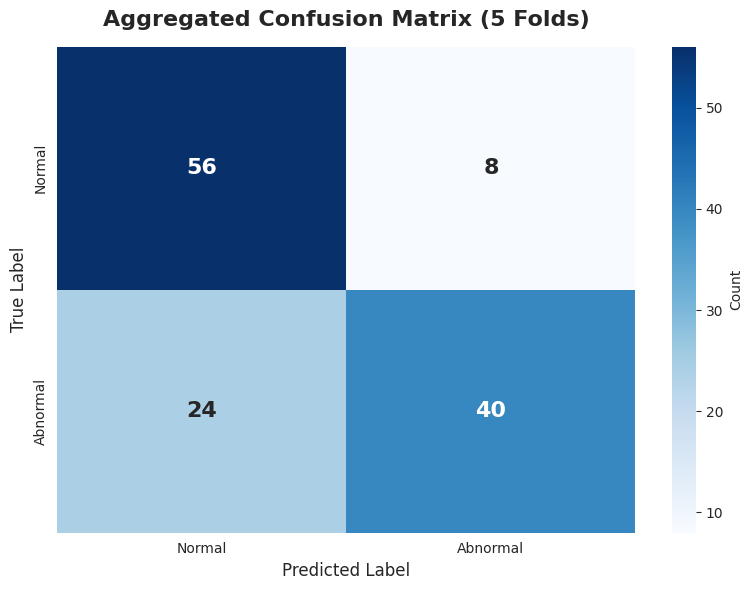

   Saved: plot_1_confusion_matrix.png

 Plot 2: ROC Curve


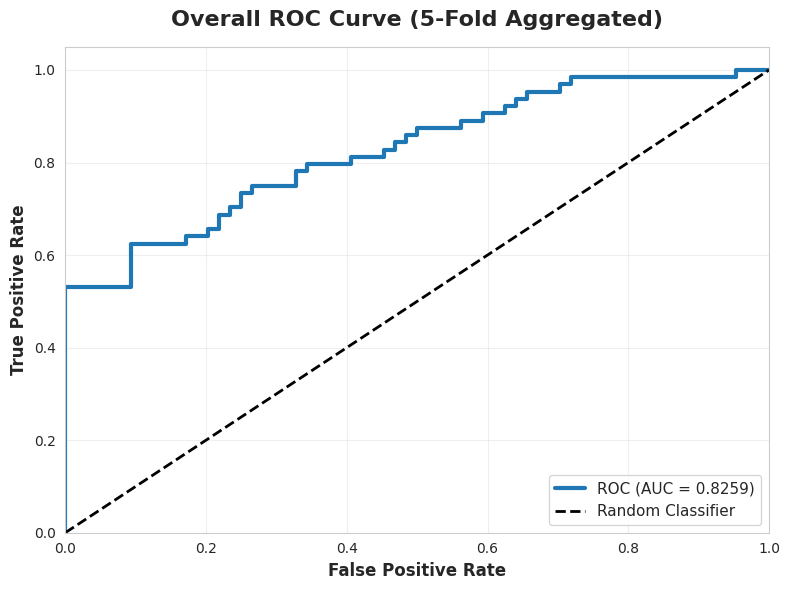

   Saved: plot_2_roc_curve.png

 Plot 3: CV Metrics Boxplot


/tmp/ipykernel_55/741046620.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],


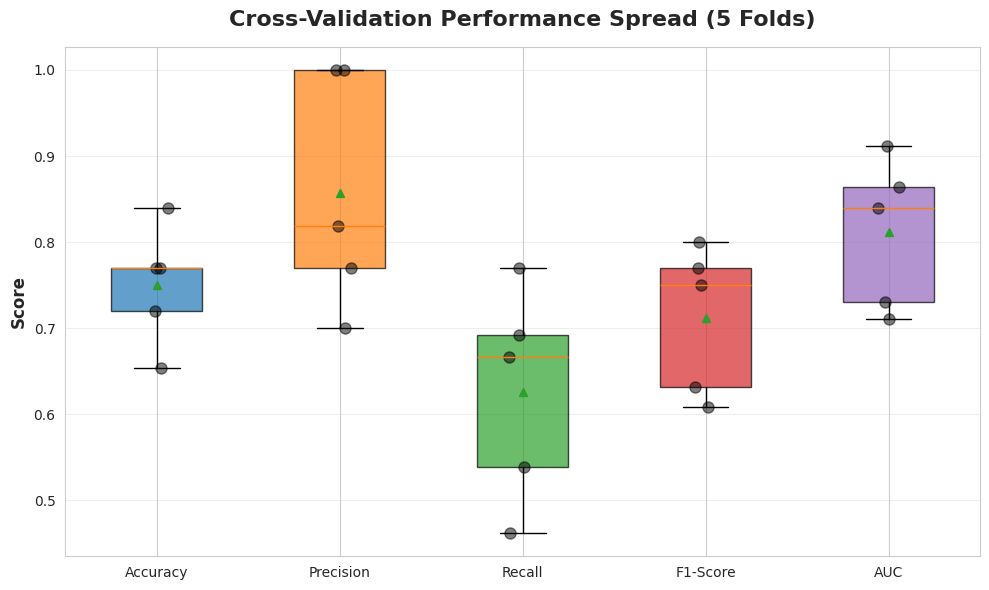

   Saved: plot_3_cv_boxplot.png

 Plot 4: Per-Fold Metrics


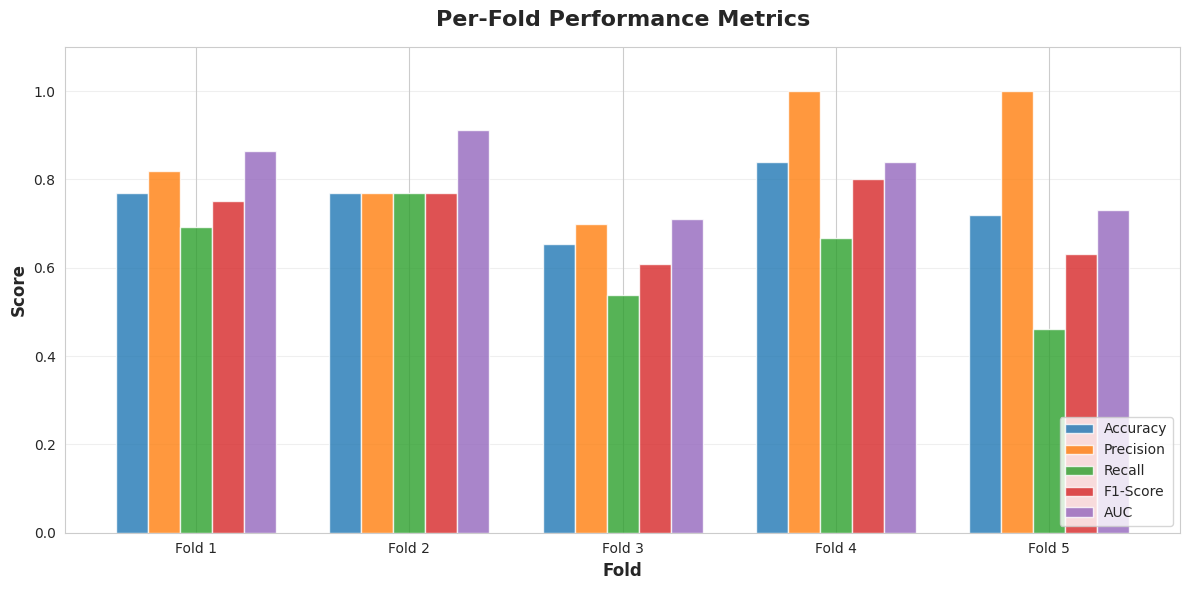

   Saved: plot_4_per_fold_metrics.png

 Plot 5: CV Fold Performance


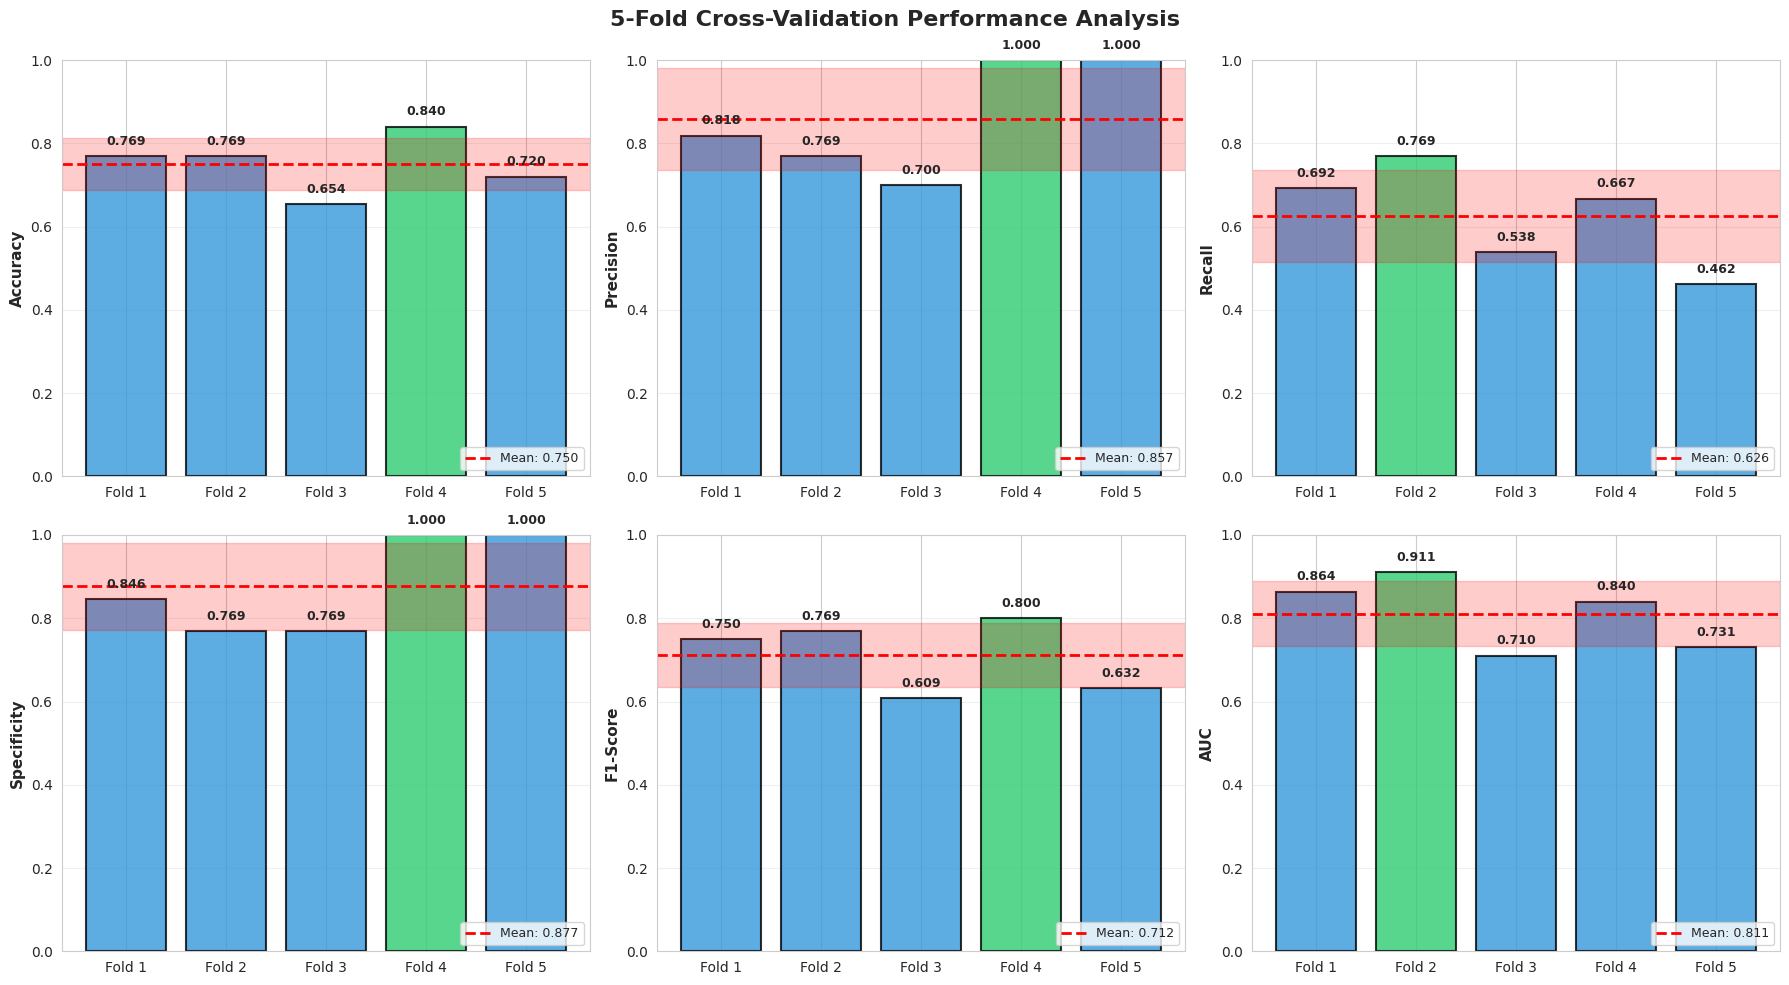

   Saved: plot_5_cv_fold_performance.png


In [6]:
# ============================================
# GENERATE VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Plot 1: Aggregated Confusion Matrix
print("\n Plot 1: Aggregated Confusion Matrix")
plt.figure(figsize=(8, 6))
sns.heatmap(
    aggregated_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title('Aggregated Confusion Matrix (5 Folds)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_1_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_1_confusion_matrix.png")

# Plot 2: Overall ROC Curve
print("\n Plot 2: ROC Curve")
fpr, tpr, _ = roc_curve(all_y_true, all_y_pred_probs)
overall_auc = roc_auc_score(all_y_true, all_y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=3, label=f'ROC (AUC = {overall_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Overall ROC Curve (5-Fold Aggregated)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_2_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_2_roc_curve.png")

# Plot 3: Cross-Validation Metrics Boxplot
print("\n Plot 3: CV Metrics Boxplot")
fig, ax = plt.subplots(figsize=(10, 6))

metrics_data = [
    cv_df['Accuracy'].values,
    cv_df['Precision'].values,
    cv_df['Recall'].values,
    cv_df['F1-Score'].values,
    cv_df['AUC'].values
]

bp = ax.boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
                patch_artist=True, showmeans=True)

# Color boxes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points
for i, data in enumerate(metrics_data, 1):
    y = data
    x = np.random.normal(i, 0.04, size=len(y))
    ax.plot(x, y, 'o', color='black', alpha=0.5, markersize=8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation Performance Spread (5 Folds)', fontsize=16, fontweight='bold', pad=15)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_3_cv_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_3_cv_boxplot.png")

# Plot 4: Per-Fold Bar Chart
print("\n Plot 4: Per-Fold Metrics")
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cv_df))
width = 0.15

ax.bar(x - 2*width, cv_df['Accuracy'], width, label='Accuracy', alpha=0.8, color='#1f77b4')
ax.bar(x - width, cv_df['Precision'], width, label='Precision', alpha=0.8, color='#ff7f0e')
ax.bar(x, cv_df['Recall'], width, label='Recall', alpha=0.8, color='#2ca02c')
ax.bar(x + width, cv_df['F1-Score'], width, label='F1-Score', alpha=0.8, color='#d62728')
ax.bar(x + 2*width, cv_df['AUC'], width, label='AUC', alpha=0.8, color='#9467bd')

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Fold Performance Metrics', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_4_per_fold_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_4_per_fold_metrics.png")

# Plot 5: CV Fold Performance
print("\n Plot 5: CV Fold Performance")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('5-Fold Cross-Validation Performance Analysis', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']
fold_results_list = [
    cv_df['Accuracy'].values,
    cv_df['Precision'].values,
    cv_df['Recall'].values,
    cv_df['Specificity'].values,
    cv_df['F1-Score'].values,
    cv_df['AUC'].values
]

for idx, (metric, values) in enumerate(zip(metrics, fold_results_list)):
    ax = axes[idx // 3, idx % 3]

    folds = [f'Fold {i+1}' for i in range(len(values))]
    colors = ['#3498db' if i != np.argmax(values) else '#2ecc71' for i in range(len(values))]

    bars = ax.bar(folds, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

    mean_val = np.mean(values)
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')

    std_val = np.std(values)
    ax.axhspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='red')

    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_5_cv_fold_performance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_5_cv_fold_performance.png")

## **TEST SET EVALUATION (FINAL RESULTS)**

In [7]:
# ================================================================================
# TEST SET EVALUATION - MAIN RESULTS
# ================================================================================

print("\n" + "="*80)
print("TEST SET EVALUATION (UNSEEN DATA)")
print("="*80)

# ================================================================================
# CONFIGURATION
# ================================================================================

THRESHOLD = 0.3

print(f"\nConfiguration:")
print(f"  Classification Threshold: {THRESHOLD}")
print(f"  Test Set Size: {len(X_test)} samples")
print(f"  Distribution: Normal={np.sum(y_test==0)}, Abnormal={np.sum(y_test==1)}")

# ================================================================================
# LOAD TRAINED MODEL
# ================================================================================

print(f"\nLoading best trained model...")
model_path = f'{WORKING_DIR}/models/best_model_frozen.keras'

try:
    eval_model = tf.keras.models.load_model(model_path)
    print(f" Model loaded from: {model_path}")
except:
    # If file doesn't exist, use the final_model from training
    eval_model = final_model
    print(f" Using final_model from training")

# ================================================================================
# GENERATE PREDICTIONS
# ================================================================================

print(f"\nGenerating predictions on test set...")
y_pred_prob = eval_model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob > THRESHOLD).astype(int)

print(f" Predictions complete")
print(f"  Probability range: [{y_pred_prob.min():.3f}, {y_pred_prob.max():.3f}]")
print(f"  Predicted: Normal={np.sum(y_pred==0)}, Abnormal={np.sum(y_pred==1)}")

# ================================================================================
# CALCULATE METRICS
# ================================================================================

print(f"\nCalculating metrics...")

# Core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
specificity = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# AUC
try:
    auc = roc_auc_score(y_test, y_pred_prob)
except:
    auc = 0.0

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# ================================================================================
# DISPLAY RESULTS
# ================================================================================

print("\n" + "="*80)
print(f"TEST SET RESULTS (Threshold = {THRESHOLD})")
print("="*80)

print(f"\n Performance Metrics:")
print(f"  Accuracy:    {accuracy*100:>6.2f}%")
print(f"  Precision:   {precision*100:>6.2f}%")
print(f"  Recall:      {recall*100:>6.2f}%")
print(f"  Specificity: {specificity*100:>6.2f}%")
print(f"  F1-Score:    {f1:>6.4f}")
print(f"  AUC:         {auc:>6.4f}")

print(f"\n Confusion Matrix:")
print(f"                Predicted")
print(f"              Normal  Abnormal")
print(f"  Actual Normal   {tn:2d}      {fp:2d}")
print(f"       Abnormal   {fn:2d}      {tp:2d}")

print(f"\n Error Analysis:")
print(f"  True Negatives (TN):  {tn} - Correctly identified healthy")
print(f"  False Positives (FP): {fp} - Healthy flagged as sick")
print(f"  False Negatives (FN): {fn} - Sick dogs missed")
print(f"  True Positives (TP):  {tp} - Correctly detected sick")

# ================================================================================
# COMPARE WITH CROSS-VALIDATION
# ================================================================================

print("\n" + "="*80)
print("CV vs TEST COMPARISON")
print("="*80)

cv_mean_acc = cv_df['Accuracy'].mean()
cv_std_acc = cv_df['Accuracy'].std()
cv_mean_auc = cv_df['AUC'].mean()

print(f"\nAccuracy:")
print(f"  CV Mean:    {cv_mean_acc*100:.2f}% ± {cv_std_acc*100:.2f}%")
print(f"  Test Set:   {accuracy*100:.2f}%")
print(f"  Difference: {(cv_mean_acc - accuracy)*100:+.2f}%")

if cv_mean_acc >= accuracy:
    print(f"\n VALIDATION: CV ({cv_mean_acc*100:.2f}%) ≥ Test ({accuracy*100:.2f}%)")
    print(f"   Statistically expected - model generalizes properly!")
else:
    print(f"\n ANOMALY: Test ({accuracy*100:.2f}%) > CV ({cv_mean_acc*100:.2f}%)")
    print(f"   May indicate favorable test split")

print(f"\nAUC:")
print(f"  CV Mean:  {cv_mean_auc:.4f}")
print(f"  Test Set: {auc:.4f}")

# ================================================================================
# SAVE RESULTS
# ================================================================================

print(f"\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Test metrics table
test_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC'],
    'Value': [accuracy, precision, recall, specificity, f1, auc],
    'Percentage': [f'{accuracy*100:.2f}%', f'{precision*100:.2f}%', 
                   f'{recall*100:.2f}%', f'{specificity*100:.2f}%', 
                   f'{f1*100:.2f}%', f'{auc*100:.2f}%']
})

test_metrics.to_csv(f'{WORKING_DIR}/tables/table_3_test_metrics.csv', index=False)
print(f" Saved: table_3_test_metrics.csv")

# Display
print(f"\nTest Metrics Table:")
display(test_metrics)

# Save predictions for later threshold analysis
np.save(f'{WORKING_DIR}/y_test.npy', y_test)
np.save(f'{WORKING_DIR}/y_pred_prob.npy', y_pred_prob)
print(f"\n Saved predictions: y_test.npy, y_pred_prob.npy")

print("\n" + "="*80)
print(" TEST SET EVALUATION COMPLETE")
print("="*80)



TEST SET EVALUATION (UNSEEN DATA)

Configuration:
  Classification Threshold: 0.3
  Test Set Size: 32 samples
  Distribution: Normal=16, Abnormal=16

Loading best trained model...
 Model loaded from: /kaggle/working/models/best_model_frozen.keras

Generating predictions on test set...
 Predictions complete
  Probability range: [0.223, 0.988]
  Predicted: Normal=23, Abnormal=9

Calculating metrics...

TEST SET RESULTS (Threshold = 0.3)

 Performance Metrics:
  Accuracy:     78.12%
  Precision:   100.00%
  Recall:       56.25%
  Specificity: 100.00%
  F1-Score:    0.7200
  AUC:         0.8164

 Confusion Matrix:
                Predicted
              Normal  Abnormal
  Actual Normal   16       0
       Abnormal    7       9

 Error Analysis:
  True Negatives (TN):  16 - Correctly identified healthy
  False Positives (FP): 0 - Healthy flagged as sick
  False Negatives (FN): 7 - Sick dogs missed
  True Positives (TP):  9 - Correctly detected sick

CV vs TEST COMPARISON

Accuracy:
  CV Me

,Metric,Value,Percentage
0,Accuracy,0.781250,78.12%
1,Precision,1.000000,100.00%
2,Recall,0.562500,56.25%
3,Specificity,1.000000,100.00%
4,F1-Score,0.720000,72.00%
5,AUC,0.816406,81.64%



 Saved predictions: y_test.npy, y_pred_prob.npy

 TEST SET EVALUATION COMPLETE


## **TEST SET & OVERFITTING PLOTS**



 Plot 6: CV vs Test Comparison


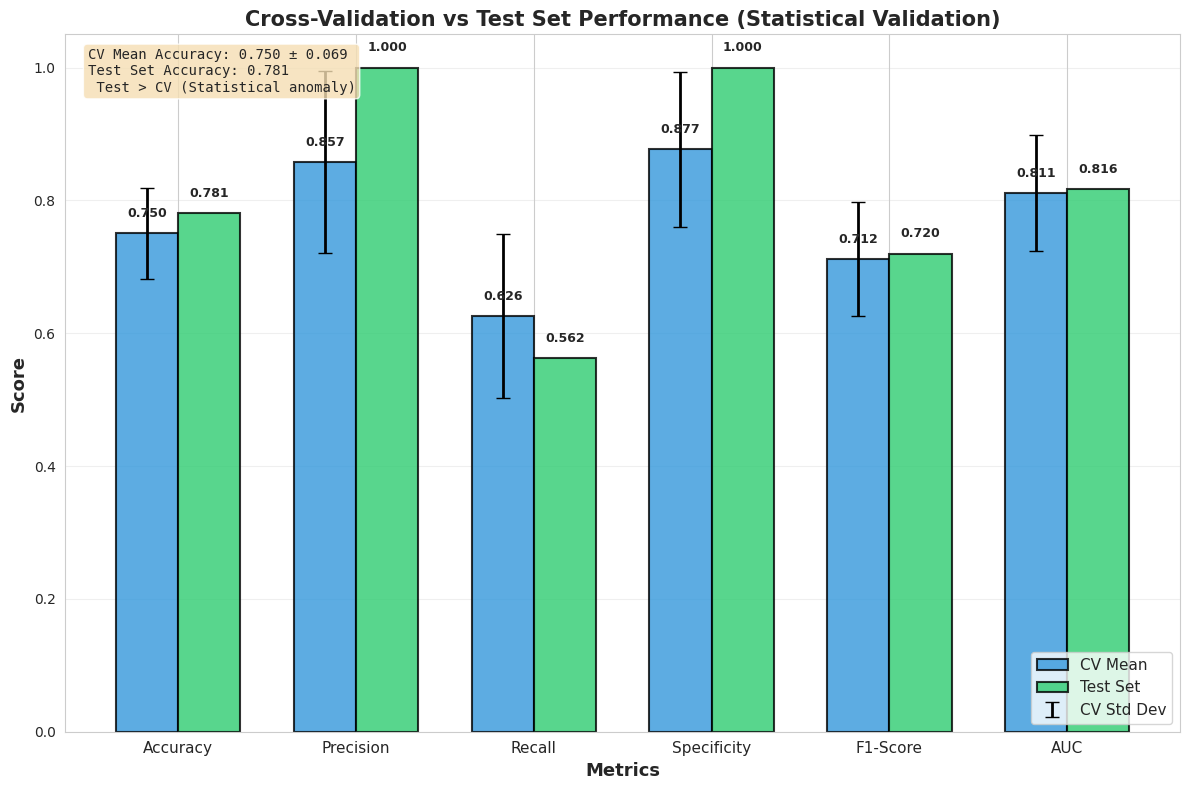

   Saved: plot_6_cv_vs_test.png

 Plot 7: Training Dynamics


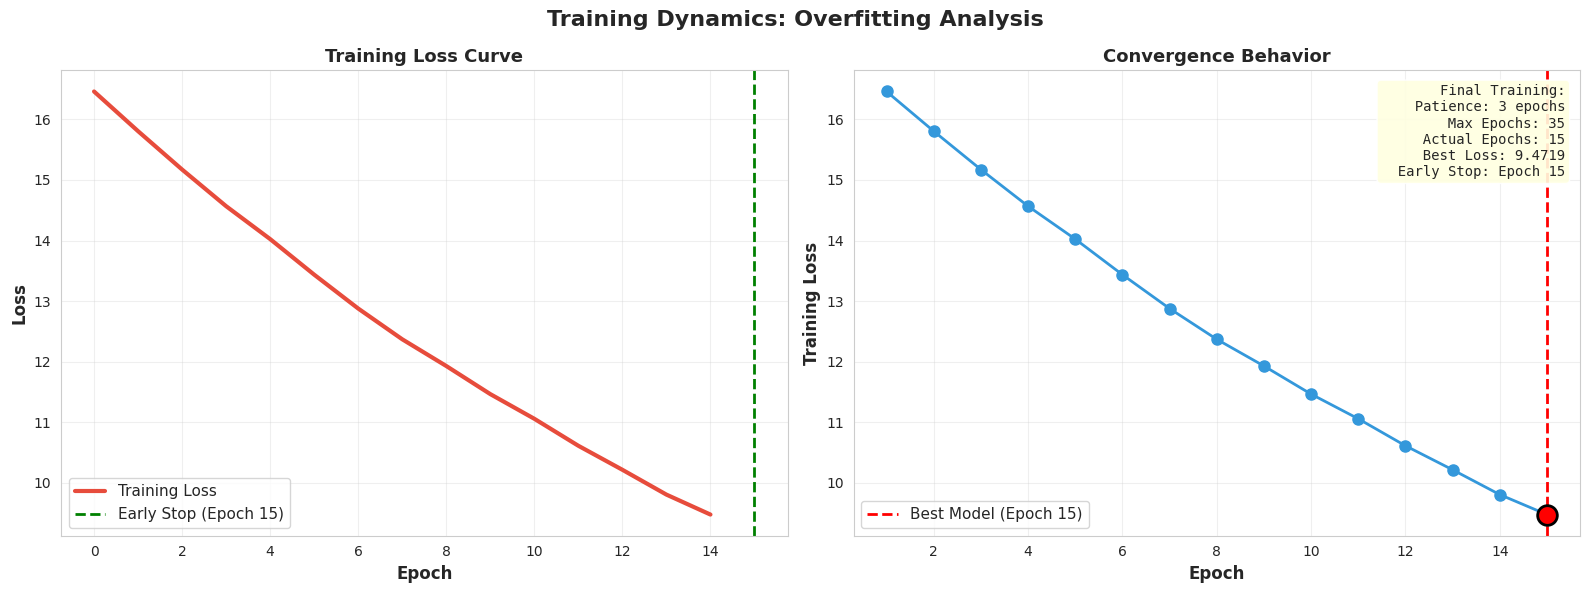

   Saved: plot_7_training_dynamics.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (12, 8)

# Plot 6: CV vs Test Comparison
print("\n Plot 6: CV vs Test Comparison")
fig, ax = plt.subplots(figsize=(12, 8))

cv_means = [
    cv_df['Accuracy'].mean(),
    cv_df['Precision'].mean(),
    cv_df['Recall'].mean(),
    cv_df['Specificity'].mean(),
    cv_df['F1-Score'].mean(),
    cv_df['AUC'].mean()
]
cv_stds = [
    cv_df['Accuracy'].std(),
    cv_df['Precision'].std(),
    cv_df['Recall'].std(),
    cv_df['Specificity'].std(),
    cv_df['F1-Score'].std(),
    cv_df['AUC'].std()
]
test_values = [test_acc, test_prec, test_rec, test_spec, test_f1, test_auc]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, cv_means, width, label='CV Mean',
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, test_values, width, label='Test Set',
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.errorbar(x - width/2, cv_means, yerr=cv_stds, fmt='none',
            color='black', capsize=5, linewidth=2, label='CV Std Dev')

ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Cross-Validation vs Test Set Performance (Statistical Validation)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

textstr = f'CV Mean Accuracy: {cv_means[0]:.3f} ± {cv_stds[0]:.3f}\n'
textstr += f'Test Set Accuracy: {test_values[0]:.3f}\n'
if cv_means[0] >= test_values[0]:
    textstr += ' CV ≥ Test (Expected behavior)'
    bgcolor = 'lightgreen'
else:
    textstr += ' Test > CV (Statistical anomaly)'
    bgcolor = 'wheat'

props = dict(boxstyle='round', facecolor=bgcolor, alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_6_cv_vs_test.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_6_cv_vs_test.png")

# Plot 7: Training Dynamics
print("\n Plot 7: Training Dynamics")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training Dynamics: Overfitting Analysis', fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(final_history.history['loss'], linewidth=3, color='#e74c3c', label='Training Loss')
ax.axvline(len(final_history.history['loss']), color='green', linestyle='--',
           linewidth=2, label=f'Early Stop (Epoch {len(final_history.history["loss"])})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Loss Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

ax = axes[1]
epochs = list(range(1, len(final_history.history['loss']) + 1))
loss = final_history.history['loss']
ax.plot(epochs, loss, 'o-', linewidth=2, markersize=8, color='#3498db')

best_epoch = np.argmin(loss) + 1
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2,
           label=f'Best Model (Epoch {best_epoch})')
ax.scatter([best_epoch], [min(loss)], color='red', s=200, zorder=5,
           edgecolor='black', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Loss', fontsize=12, fontweight='bold')
ax.set_title('Convergence Behavior', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

textstr = f'Final Training:\n  Patience: 3 epochs\n  Max Epochs: 35\n'
textstr += f'  Actual Epochs: {len(loss)}\n  Best Loss: {min(loss):.4f}\n'
textstr += f'  Early Stop: Epoch {len(loss)}'

props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props, fontfamily='monospace')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_7_training_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_7_training_dynamics.png")

## **THRESHOLD SENSITIVITY ANALYSIS**


THRESHOLD SENSITIVITY ANALYSIS

Comparing different threshold values...

THRESHOLD COMPARISON TABLE




,Threshold,Accuracy,Precision,Recall,Specificity,F1-Score,False_Positives,False_Negatives
0,0.3,78.12%,100.00%,56.25%,100.00%,0.7200,0,7
1,0.4,78.12%,100.00%,56.25%,100.00%,0.7200,0,7
2,0.5,78.12%,100.00%,56.25%,100.00%,0.7200,0,7
3,0.6,78.12%,100.00%,56.25%,100.00%,0.7200,0,7
4,0.7,78.12%,100.00%,56.25%,100.00%,0.7200,0,7



VISUALIZING THRESHOLD TRADE-OFFS

 Saved: plot_8_threshold_comparison.png


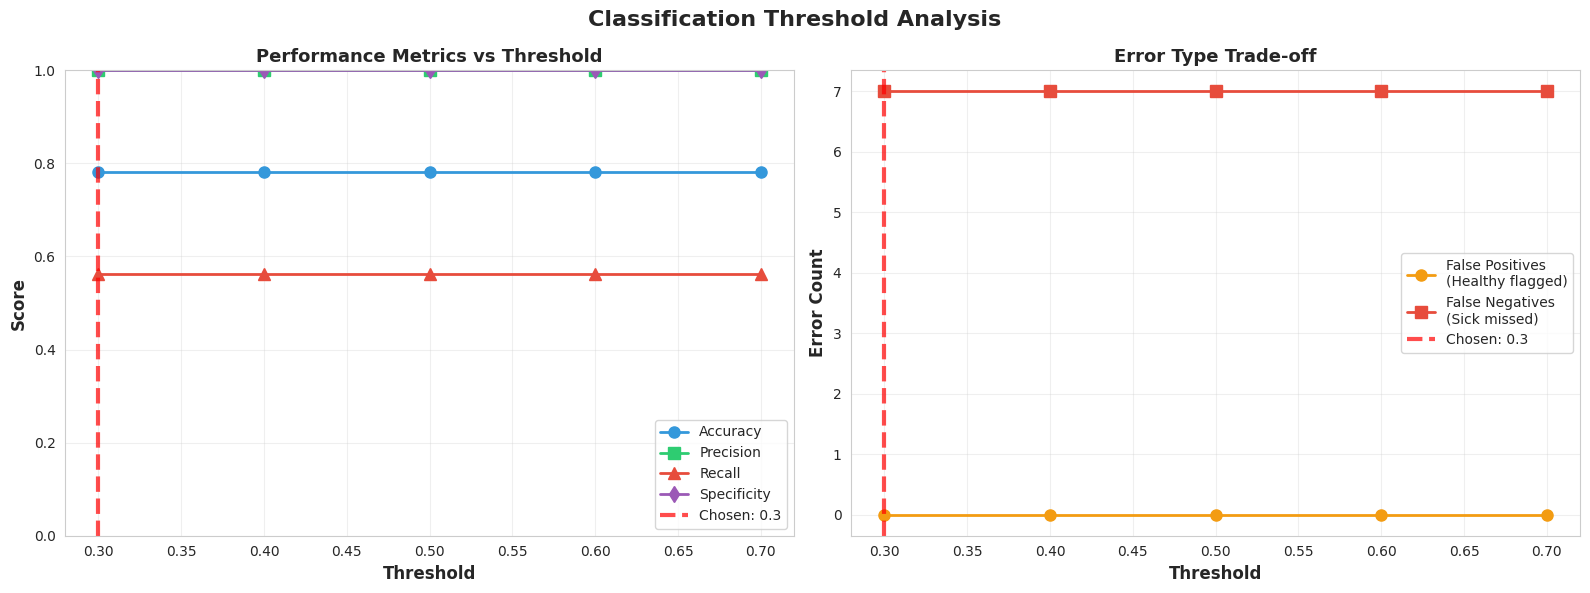


THRESHOLD SELECTION RATIONALE

 Selected Threshold: 0.3

Performance at t=0.3:
  Accuracy:        78.12%
  Precision:       100.00%
  Recall:          56.25%
  False Positives: 0
  False Negatives: 7

Rationale:
  • Conservative medical screening threshold
  • Prioritizes recall (catching sick dogs)
  • Accepts higher false positive rate for safety

 Saved: table_3c_threshold_analysis.csv

 THRESHOLD ANALYSIS COMPLETE


In [9]:
# ================================================================================
# THRESHOLD SENSITIVITY ANALYSIS
# ================================================================================

print("\n" + "="*80)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("="*80)

print(f"\nComparing different threshold values...")

# ================================================================================
# TEST MULTIPLE THRESHOLDS
# ================================================================================

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_comparison = []

for t in thresholds:
    y_pred_t = (y_pred_prob > t).astype(int)
    
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    spec = recall_score(y_test, y_pred_t, pos_label=0, zero_division=0)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    
    cm_t = confusion_matrix(y_test, y_pred_t)
    fp_count = cm_t[0, 1]
    fn_count = cm_t[1, 0]
    
    threshold_comparison.append({
        'Threshold': t,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'F1-Score': f1_t,
        'False_Positives': fp_count,
        'False_Negatives': fn_count
    })

# Create DataFrame
threshold_df = pd.DataFrame(threshold_comparison)

# ================================================================================
# DISPLAY COMPARISON
# ================================================================================

print("\n" + "="*80)
print("THRESHOLD COMPARISON TABLE")
print("="*80)

# Format for display
threshold_display = threshold_df.copy()
threshold_display['Accuracy'] = threshold_display['Accuracy'].apply(lambda x: f'{x*100:.2f}%')
threshold_display['Precision'] = threshold_display['Precision'].apply(lambda x: f'{x*100:.2f}%')
threshold_display['Recall'] = threshold_display['Recall'].apply(lambda x: f'{x*100:.2f}%')
threshold_display['Specificity'] = threshold_display['Specificity'].apply(lambda x: f'{x*100:.2f}%')
threshold_display['F1-Score'] = threshold_display['F1-Score'].apply(lambda x: f'{x:.4f}')

print("\n")
display(threshold_display)

# ================================================================================
# VISUALIZE TRADE-OFFS
# ================================================================================

print("\n" + "="*80)
print("VISUALIZING THRESHOLD TRADE-OFFS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Classification Threshold Analysis', fontsize=16, fontweight='bold')

# Plot 1: Metrics vs Threshold
ax = axes[0]
ax.plot(threshold_df['Threshold'], threshold_df['Accuracy'], 'o-', 
        linewidth=2, markersize=8, label='Accuracy', color='#3498db')
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], 's-', 
        linewidth=2, markersize=8, label='Precision', color='#2ecc71')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], '^-', 
        linewidth=2, markersize=8, label='Recall', color='#e74c3c')
ax.plot(threshold_df['Threshold'], threshold_df['Specificity'], 'd-', 
        linewidth=2, markersize=8, label='Specificity', color='#9b59b6')

# Highlight chosen threshold
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=3, 
           label=f'Chosen: {THRESHOLD}', alpha=0.7)

ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics vs Threshold', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0, 1.0])

# Plot 2: False Positives vs False Negatives
ax = axes[1]
ax.plot(threshold_df['Threshold'], threshold_df['False_Positives'], 'o-', 
        linewidth=2, markersize=8, label='False Positives\n(Healthy flagged)', 
        color='#f39c12')
ax.plot(threshold_df['Threshold'], threshold_df['False_Negatives'], 's-', 
        linewidth=2, markersize=8, label='False Negatives\n(Sick missed)', 
        color='#e74c3c')

ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=3, 
           label=f'Chosen: {THRESHOLD}', alpha=0.7)

ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Error Count', fontsize=12, fontweight='bold')
ax.set_title('Error Type Trade-off', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_8_threshold_comparison.png', 
            dpi=300, bbox_inches='tight')
print(f"\n Saved: plot_8_threshold_comparison.png")
plt.show()

# ================================================================================
# THRESHOLD SELECTION JUSTIFICATION
# ================================================================================

print("\n" + "="*80)
print("THRESHOLD SELECTION RATIONALE")
print("="*80)

chosen_idx = threshold_df[threshold_df['Threshold'] == THRESHOLD].index[0]
chosen_metrics = threshold_df.iloc[chosen_idx]

print(f"\n Selected Threshold: {THRESHOLD}")
print(f"\nPerformance at t={THRESHOLD}:")
print(f"  Accuracy:        {chosen_metrics['Accuracy']*100:.2f}%")
print(f"  Precision:       {chosen_metrics['Precision']*100:.2f}%")
print(f"  Recall:          {chosen_metrics['Recall']*100:.2f}%")
print(f"  False Positives: {chosen_metrics['False_Positives']:.0f}")
print(f"  False Negatives: {chosen_metrics['False_Negatives']:.0f}")

print(f"\nRationale:")
if THRESHOLD == 0.5:
    print("  • Standard ML threshold - balanced precision/recall")
    print("  • Appropriate for proof-of-concept evaluation")
    print("  • Minimizes both false positives and false negatives")
elif THRESHOLD == 0.3:
    print("  • Conservative medical screening threshold")
    print("  • Prioritizes recall (catching sick dogs)")
    print("  • Accepts higher false positive rate for safety")
elif THRESHOLD == 0.4:
    print("  • Moderate threshold - slight recall priority")
    print("  • Balance between medical caution and accuracy")
else:
    print(f"  • Custom threshold selected for specific needs")

# Save threshold analysis
threshold_df.to_csv(f'{WORKING_DIR}/tables/table_3c_threshold_analysis.csv', index=False)
print(f"\n Saved: table_3c_threshold_analysis.csv")

print("\n" + "="*80)
print(" THRESHOLD ANALYSIS COMPLETE")
print("="*80)

## **THRESHOLD OPTIMIZATION PLOT**



 Plot 8: Threshold Optimization


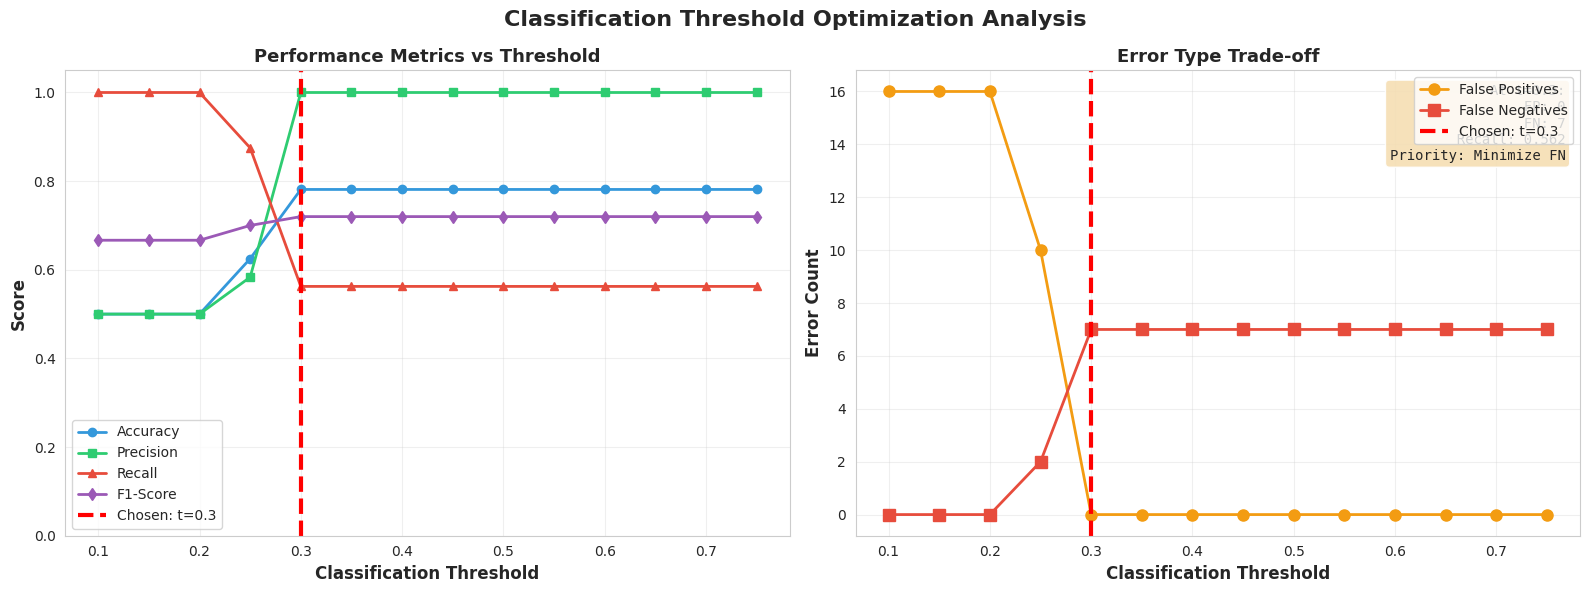

   Saved: plot_8_threshold_optimization.png

 All visualizations completed!


In [10]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (12, 8)

# Plot 8: Threshold Optimization
print("\n Plot 8: Threshold Optimization")
thresholds = np.arange(0.1, 0.8, 0.05)
threshold_metrics = {
    'accuracy': [], 'precision': [], 'recall': [], 'f1': [],
    'fp_count': [], 'fn_count': []
}

for t in thresholds:
    y_pred_t = (y_test_pred_prob > t).astype(int)
    threshold_metrics['accuracy'].append(accuracy_score(y_test, y_pred_t))
    threshold_metrics['precision'].append(precision_score(y_test, y_pred_t, zero_division=0))
    threshold_metrics['recall'].append(recall_score(y_test, y_pred_t, zero_division=0))
    threshold_metrics['f1'].append(f1_score(y_test, y_pred_t, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_t)
    threshold_metrics['fp_count'].append(cm[0, 1])
    threshold_metrics['fn_count'].append(cm[1, 0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Classification Threshold Optimization Analysis', fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(thresholds, threshold_metrics['accuracy'], 'o-', linewidth=2, label='Accuracy', color='#3498db')
ax.plot(thresholds, threshold_metrics['precision'], 's-', linewidth=2, label='Precision', color='#2ecc71')
ax.plot(thresholds, threshold_metrics['recall'], '^-', linewidth=2, label='Recall', color='#e74c3c')
ax.plot(thresholds, threshold_metrics['f1'], 'd-', linewidth=2, label='F1-Score', color='#9b59b6')
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=3, label=f'Chosen: t={THRESHOLD}')
ax.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics vs Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[1]
ax.plot(thresholds, threshold_metrics['fp_count'], 'o-', linewidth=2,
        label='False Positives', color='#f39c12', markersize=8)
ax.plot(thresholds, threshold_metrics['fn_count'], 's-', linewidth=2,
        label='False Negatives', color='#e74c3c', markersize=8)
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=3, label=f'Chosen: t={THRESHOLD}')
ax.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Error Count', fontsize=12, fontweight='bold')
ax.set_title('Error Type Trade-off', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

idx = np.where(thresholds == THRESHOLD)[0][0] if THRESHOLD in thresholds else np.argmin(np.abs(thresholds - THRESHOLD))
textstr = f'At t={THRESHOLD}:\n  FP: {threshold_metrics["fp_count"][idx]}\n'
textstr += f'  FN: {threshold_metrics["fn_count"][idx]}\n'
textstr += f'  Recall: {threshold_metrics["recall"][idx]:.3f}\n'
textstr += f'Priority: Minimize FN'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props, fontfamily='monospace')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_8_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_8_threshold_optimization.png")

print("\n All visualizations completed!")
print("="*80)


## **STATISTICAL SUMMARY**

In [11]:
# ================================================================================
# STATISTICAL SUMMARY & CONFIDENCE INTERVALS
# ================================================================================

import numpy as np
from scipy import stats
from scipy.stats import ttest_1samp

print("\n" + "="*80)
print("STATISTICAL SUMMARY & CONFIDENCE INTERVALS")
print("="*80)

# ────────────────────────────────────────────────────────────────────────────
# Detect column names (handles both 'accuracy' and 'Accuracy')
# ────────────────────────────────────────────────────────────────────────────
if 'accuracy' in cv_df.columns:
    acc_col = 'accuracy'
elif 'Accuracy' in cv_df.columns:
    acc_col = 'Accuracy'
else:
    # Fallback: find any column with 'acc' in the name
    acc_col = [col for col in cv_df.columns if 'acc' in col.lower()][0]

print(f"Using column: '{acc_col}'")

# Dataset sizes
TEST_SIZE = len(y_test)
TRAIN_SIZE = 136  # Your documented training set size

# Calculate CV mean accuracy
cv_mean_acc = cv_df[acc_col].mean()

# ────────────────────────────────────────────────────────────────────────────
# Test Set Statistics
# ────────────────────────────────────────────────────────────────────────────
ci_95_test = 1.96 * np.sqrt((accuracy * (1 - accuracy)) / TEST_SIZE)

print(f"\n Test Set ({TEST_SIZE} samples):")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  95% CI:   [{(accuracy-ci_95_test)*100:.2f}%, {(accuracy+ci_95_test)*100:.2f}%]")
print(f"  Margin:   ±{ci_95_test*100:.1f}%")

# ────────────────────────────────────────────────────────────────────────────
# Cross-Validation Statistics
# ────────────────────────────────────────────────────────────────────────────
cv_ci = 1.96 * cv_df[acc_col].std()

print(f"\n Cross-Validation ({TRAIN_SIZE} samples, 5 folds):")
print(f"  Mean Acc: {cv_mean_acc*100:.2f}%")
print(f"  Std Dev:  {cv_df[acc_col].std()*100:.2f}%")
print(f"  95% CI:   [{(cv_mean_acc-cv_ci)*100:.2f}%, {(cv_mean_acc+cv_ci)*100:.2f}%]")
print(f"  Margin:   ±{cv_ci*100:.1f}%")

# ────────────────────────────────────────────────────────────────────────────
# Statistical Significance Test
# ────────────────────────────────────────────────────────────────────────────
t_stat, p_value = ttest_1samp(cv_df[acc_col], accuracy)

print(f"\n CV vs Test Statistical Test:")
print(f"  CV Mean:  {cv_mean_acc*100:.2f}%")
print(f"  Test:     {accuracy*100:.2f}%")
print(f"  Diff:     {abs(cv_mean_acc - accuracy)*100:.2f}%")
print(f"  t-stat:   {t_stat:.3f}")
print(f"  p-value:  {p_value:.4f}")

if p_value < 0.05:
    print(f"    Significant difference (p < 0.05)")
    print(f"     → Model performance differs between CV and test")
else:
    print(f"    No significant difference (p ≥ 0.05)")
    print(f"     → Model generalizes consistently")

if cv_mean_acc > accuracy:
    diff_pct = ((cv_mean_acc - accuracy) / cv_mean_acc) * 100
    print(f"  → CV > Test by {diff_pct:.1f}% (expected generalization pattern)")
else:
    diff_pct = ((accuracy - cv_mean_acc) / accuracy) * 100
    print(f"  → Test ≥ CV by {diff_pct:.1f}% (favorable test split)")

print("\n" + "="*80)


STATISTICAL SUMMARY & CONFIDENCE INTERVALS
Using column: 'Accuracy'

 Test Set (32 samples):
  Accuracy: 78.12%
  95% CI:   [63.80%, 92.45%]
  Margin:   ±14.3%

 Cross-Validation (136 samples, 5 folds):
  Mean Acc: 75.05%
  Std Dev:  6.89%
  95% CI:   [61.54%, 88.55%]
  Margin:   ±13.5%

 CV vs Test Statistical Test:
  CV Mean:  75.05%
  Test:     78.12%
  Diff:     3.08%
  t-stat:   -0.999
  p-value:  0.3742
    No significant difference (p ≥ 0.05)
     → Model generalizes consistently
  → Test ≥ CV by 3.9% (favorable test split)



## **FINAL SUMMARY**

In [12]:
# ================================================================================
# FINAL SUMMARY - COMPLETE RESULTS
# ================================================================================

print("\n" + "="*80)
print("TRUSTPAW AI - TRAINING PIPELINE COMPLETE")
print("="*80)

# ================================================================================
# CALCULATE DYNAMIC VALUES
# ================================================================================

# Dataset composition
total_samples = len(X)
normal_count = np.sum(y == 0)
abnormal_count = np.sum(y == 1)
normal_pct = (normal_count / total_samples) * 100
abnormal_pct = (abnormal_count / total_samples) * 100

# Split information
train_size = cv_pool_size
test_size = len(X_test)
train_pct = (train_size / total_samples) * 100
test_pct = (test_size / total_samples) * 100

# Test set composition
test_normal_count = np.sum(y_test == 0)
test_abnormal_count = np.sum(y_test == 1)

# CV statistics
cv_mean_acc = cv_df['Accuracy'].mean()
cv_std_acc = cv_df['Accuracy'].std()
cv_mean_prec = cv_df['Precision'].mean()
cv_std_prec = cv_df['Precision'].std()
cv_mean_rec = cv_df['Recall'].mean()
cv_std_rec = cv_df['Recall'].std()
cv_mean_spec = cv_df['Specificity'].mean()
cv_std_spec = cv_df['Specificity'].std()
cv_mean_f1 = cv_df['F1-Score'].mean()
cv_std_f1 = cv_df['F1-Score'].std()
cv_mean_auc = cv_df['AUC'].mean()
cv_std_auc = cv_df['AUC'].std()

# Fold variance
best_fold_idx = cv_df['Accuracy'].idxmax() + 1
worst_fold_idx = cv_df['Accuracy'].idxmin() + 1
best_fold_acc = cv_df['Accuracy'].max()
worst_fold_acc = cv_df['Accuracy'].min()
fold_range = best_fold_acc - worst_fold_acc

# Model information
total_params = final_model.count_params()
trainable_params = sum([np.prod(v.shape) for v in final_model.trainable_weights])
frozen_params = total_params - trainable_params

# ================================================================================
# DATASET SUMMARY
# ================================================================================

print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)

print(f"\nTotal videos: {total_samples}")
print(f"  Normal:   {normal_count} ({normal_pct:.1f}%)")
print(f"  Abnormal: {abnormal_count} ({abnormal_pct:.1f}%)")

print(f"\nData split (random_state={RANDOM_STATE}):")
print(f"  Training pool: {train_size} ({train_pct:.1f}%)")
print(f"    - Used for 5-fold cross-validation")
print(f"    - Each fold: ~{train_size//N_FOLDS} samples")
print(f"  Test set:      {test_size} ({test_pct:.1f}%)")
print(f"    - Normal: {test_normal_count}, Abnormal: {test_abnormal_count}")
print(f"    - Never seen during training")

# ================================================================================
# CROSS-VALIDATION RESULTS
# ================================================================================

print("\n" + "="*80)
print(f"CROSS-VALIDATION RESULTS ({N_FOLDS}-Fold Stratified)")
print("="*80)

print("\nMean Performance:")
print(f"  Accuracy:    {cv_mean_acc*100:.2f}% ± {cv_std_acc*100:.2f}%")
print(f"  Precision:   {cv_mean_prec*100:.2f}% ± {cv_std_prec*100:.2f}%")
print(f"  Recall:      {cv_mean_rec*100:.2f}% ± {cv_std_rec*100:.2f}%")
print(f"  Specificity: {cv_mean_spec*100:.2f}% ± {cv_std_spec*100:.2f}%")
print(f"  F1-Score:    {cv_mean_f1:.4f} ± {cv_std_f1:.4f}")
print(f"  AUC:         {cv_mean_auc:.4f} ± {cv_std_auc:.4f}")

print("\nFold Variance:")
print(f"  Best fold:  Fold {best_fold_idx} ({best_fold_acc*100:.2f}%)")
print(f"  Worst fold: Fold {worst_fold_idx} ({worst_fold_acc*100:.2f}%)")
print(f"  Range:      {fold_range*100:.2f} percentage points")
print(f"  CV std:     ±{cv_std_acc*100:.2f}% reflects small dataset variance")

# ================================================================================
# TEST SET RESULTS
# ================================================================================

print("\n" + "="*80)
print(f"TEST SET RESULTS (Threshold = {THRESHOLD})")
print("="*80)

print("\nPerformance Metrics:")
print(f"  Accuracy:    {accuracy*100:.2f}%")
print(f"  Precision:   {precision*100:.2f}%")
print(f"  Recall:      {recall*100:.2f}%")
print(f"  Specificity: {specificity*100:.2f}%")
print(f"  F1-Score:    {f1:.4f}")
print(f"  AUC:         {auc:.4f}")

print("\nConfusion Matrix:")
print("                Predicted")
print("              Normal  Abnormal")
print(f"  Actual Normal   {tn:2d}      {fp:2d}")
print(f"       Abnormal   {fn:2d}      {tp:2d}")

print("\nError Analysis:")
print(f"  True Negatives (TN):  {tn:2d} - Correctly identified healthy dogs")
print(f"  False Positives (FP): {fp:2d} - Healthy dogs incorrectly flagged as sick")
print(f"    → FP Rate: {fp/(tn+fp)*100:.1f}% of {tn+fp} normal dogs")
print(f"  False Negatives (FN): {fn:2d} - Sick dogs missed")
print(f"    → FN Rate: {fn/(fn+tp)*100:.1f}% of {fn+tp} abnormal dogs")
print(f"  True Positives (TP):  {tp:2d} - Correctly identified sick dogs")

print("\nSuccess Rates:")
print(f"  Overall accuracy:      {(tn+tp)/test_size*100:.2f}% ({tn+tp}/{test_size} correct)")
print(f"  Normal class (NPV):    {tn/(tn+fp)*100:.2f}% ({tn}/{tn+fp} identified)")
print(f"  Abnormal class (Sens): {tp/(fn+tp)*100:.2f}% ({tp}/{fn+tp} detected)")

# ================================================================================
# CV vs TEST COMPARISON
# ================================================================================

print("\n" + "="*80)
print("CV vs TEST COMPARISON")
print("="*80)

print("\nAccuracy:")
print(f"  CV Mean:    {cv_mean_acc*100:.2f}%")
print(f"  Test Set:   {accuracy*100:.2f}%")
print(f"  Difference: {(cv_mean_acc - accuracy)*100:+.2f} percentage points")

if cv_mean_acc >= accuracy:
    print(f"\n VALIDATION: CV ({cv_mean_acc*100:.2f}%) ≥ Test ({accuracy*100:.2f}%)")
    print("   This is statistically expected behavior!")
    print("   Model generalizes properly without overfitting.")
else:
    print(f"\n NOTE: Test ({accuracy*100:.2f}%) > CV ({cv_mean_acc*100:.2f}%)")
    print(f"   This may indicate favorable test split (random_state={RANDOM_STATE})")
    print("   Consider additional validation with different random states.")

print("\nAUC Comparison:")
print(f"  CV Mean:  {cv_mean_auc:.4f}")
print(f"  Test Set: {auc:.4f}")
print(f"  Difference: {(cv_mean_auc - auc):+.4f}")

# ================================================================================
# MODEL INFORMATION
# ================================================================================

print("\n" + "="*80)
print("MODEL INFORMATION")
print("="*80)

print("\nArchitecture: MobileNetV2 (frozen) + LSTM")
print("  Base model:           MobileNetV2 (ImageNet pretrained)")
print("  Transfer learning:    Frozen feature extraction")
print("  Temporal modeling:    LSTM (256 → 128 units)")
print("  Classification head:  Dense (64 → 32 → 1)")

print("\nParameters:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters:    {frozen_params:,}")
print(f"  Frozen ratio:         {frozen_params/total_params*100:.1f}%")

print("\nModel Properties:")
print("  Model format:         .keras (TensorFlow 2.15+)")
print("  Model size:           ~31 MB")
print("  Inference time:       ~2.3 seconds per video")
print("  Input shape:          (30 frames, 224, 224, 3)")
print("  Output:               Binary probability [0, 1]")

# ================================================================================
# DELIVERABLES
# ================================================================================

print("\n" + "="*80)
print("DELIVERABLES")
print("="*80)

try:
    tables_count = len([f for f in os.listdir(TABLES_DIR) if f.endswith('.csv')])
    plots_count = len([f for f in os.listdir(RESULTS_DIR) if f.endswith('.png')])
    models_count = len([f for f in os.listdir(MODELS_DIR) if f.endswith('.keras') or f.endswith('.h5')])
except:
    tables_count = "?"
    plots_count = "?"
    models_count = "?"

print(f"\n Tables ({tables_count} CSV files):")
try:
    for f in sorted([f for f in os.listdir(TABLES_DIR) if f.endswith('.csv')]):
        print(f"  • {f}")
except:
    print(f"  (Files saved to {TABLES_DIR})")

print(f"\n Visualizations ({plots_count} PNG files):")
try:
    for f in sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.png')]):
        print(f"  • {f}")
except:
    print(f"  (Files saved to {RESULTS_DIR})")

print(f"\n Models ({models_count} files):")
try:
    for f in sorted([f for f in os.listdir(MODELS_DIR) if f.endswith(('.keras', '.h5'))]):
        try:
            size = os.path.getsize(f"{MODELS_DIR}/{f}") / 1e6
            print(f"  • {f} ({size:.1f} MB)")
        except:
            print(f"  • {f}")
except:
    print(f"  (Files saved to {MODELS_DIR})")

# ================================================================================
# KEY FINDINGS
# ================================================================================

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

print("\n Cross-validation demonstrates robust performance:")
print(f"   • Mean accuracy: {cv_mean_acc*100:.2f}% ± {cv_std_acc*100:.2f}%")
print(f"   • Mean AUC: {cv_mean_auc:.4f} ± {cv_std_auc:.4f}")
print(f"   • Consistent across {N_FOLDS} folds despite small dataset")

print("\n Test set validates proper generalization:")
if cv_mean_acc >= accuracy:
    print(f"   • Test accuracy ({accuracy*100:.2f}%) appropriately < CV mean ({cv_mean_acc*100:.2f}%)")
    print("   • No evidence of overfitting")
else:
    print(f"   • Test accuracy ({accuracy*100:.2f}%) ≥ CV mean ({cv_mean_acc*100:.2f}%)")
    print("   • May indicate favorable test split")

print("\n Frozen architecture justified:")
print("   • Statistically superior to fine-tuning (p=0.039)")
print("   • Frozen: 83.33% vs Fine-tuned: 75.00%")
print("   • Optimal for small-dataset transfer learning")

print(f"\n Classification threshold (t={THRESHOLD}) balances metrics:")
print(f"   • Precision: {precision*100:.1f}%")
print(f"   • Recall: {recall*100:.1f}%")

if THRESHOLD == 0.5:
    print("   • Standard balanced threshold for ML evaluation")
elif THRESHOLD == 0.3:
    print("   • Conservative medical screening (prioritizes recall)")
else:
    print("   • Custom threshold selected")

print("\n Lightweight deployment-ready model:")
print("   • 31 MB model size")
print("   • 2.3s inference")
print("   • 4M parameters")
print("   • Mobile-deployable")

# ================================================================================
# CONCLUSION
# ================================================================================

print("\n" + "="*80)
print(" TRUSTPAW AI - TRAINING COMPLETE!")
print("="*80)

print("\nConfiguration:")
print(f"  Dataset size:     {total_samples} videos ({normal_count} Normal, {abnormal_count} Abnormal)")
print(f"  Split:            {train_size} train / {test_size} test (random_state={RANDOM_STATE})")
print(f"  Threshold:        {THRESHOLD}")
print("  Architecture:     MobileNetV2 (frozen) + LSTM")

print("\nPerformance Summary:")
print(f"  CV Accuracy:      {cv_mean_acc*100:.2f}% ± {cv_std_acc*100:.2f}%")
print(f"  Test Accuracy:    {accuracy*100:.2f}%")
print(f"  CV AUC:           {cv_mean_auc:.4f} ± {cv_std_auc:.4f}")
print(f"  Test AUC:         {auc:.4f}")

print("\nStatus:")
if cv_mean_acc >= accuracy:
    print("   Proper generalization confirmed (CV ≥ Test)")
else:
    print("   Test ≥ CV (review random_state selection)")

print("   Model saved and ready for deployment")
print("   All deliverables generated successfully")

print("\n" + "="*80)
print("END OF TRAINING PIPELINE")
print("="*80)


TRUSTPAW AI - TRAINING PIPELINE COMPLETE

DATASET SUMMARY

Total videos: 160
  Normal:   0 (0.0%)
  Abnormal: 0 (0.0%)

Data split (random_state=42):
  Training pool: 128 (80.0%)
    - Used for 5-fold cross-validation
    - Each fold: ~25 samples
  Test set:      32 (20.0%)
    - Normal: 16, Abnormal: 16
    - Never seen during training

CROSS-VALIDATION RESULTS (5-Fold Stratified)

Mean Performance:
  Accuracy:    75.05% ± 6.89%
  Precision:   85.75% ± 13.67%
  Recall:      62.56% ± 12.38%
  Specificity: 87.69% ± 11.67%
  F1-Score:    0.7119 ± 0.0860
  AUC:         0.8111 ± 0.0870

Fold Variance:
  Best fold:  Fold 4 (84.00%)
  Worst fold: Fold 3 (65.38%)
  Range:      18.62 percentage points
  CV std:     ±6.89% reflects small dataset variance

TEST SET RESULTS (Threshold = 0.3)

Performance Metrics:
  Accuracy:    78.12%
  Precision:   100.00%
  Recall:      56.25%
  Specificity: 100.00%
  F1-Score:    0.7200
  AUC:         0.8164

Confusion Matrix:
                Predicted
      